In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_test_2014_05_12.csv" "/content/master_long_hourly_test_2014_05_12.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_train_2012_2013.csv" "/content/master_long_hourly_train_2012_2013.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_validation_2014_01_04.csv" "/content/master_long_hourly_validation_2014_01_04.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/calendar_features_hourly.csv" "/content/calendar_features_hourly.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/user_cluster_mapping.csv" "/content/user_cluster_mapping.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/evaluation_protocol.json" "/content/evaluation_protocol.json"

In [4]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.7/285.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.3 MB/s eta 0:00:00
  Attempting uninstall: tornado
    Found existing installation: tornado 6.5.1
    Uninstalling tornado-6.5.1:
      Successfully uninstalled tornado-6.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour i

In [1]:
from pathlib import Path

# Input files — long-format CSVs
TRAIN_PATH    = "/content/master_long_hourly_train_2012_2013.csv"
VAL_PATH      = "/content/master_long_hourly_validation_2014_01_04.csv"
TEST_PATH     = "/content/master_long_hourly_test_2014_05_12.csv"
CALENDAR_PATH = "/content/calendar_features_hourly.csv"
MAPPING_PATH  = "/content/user_cluster_mapping.csv"
PROTOCOL_PATH = "/content/evaluation_protocol.json"

# Output
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Model hyper-parameters
CHUNK_H       = 720         # forecast horizon per chunk (~1 month)
INPUT_SIZE    = 672         # look back 4 weeks
MAX_STEPS     = 5000
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
EARLY_STOP    = 10
VAL_CHECK     = 100
RANDOM_SEED   = 42
SCALER_TYPE   = "standard"  # normalise each series independently

In [2]:
# IMPORTS
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from neuralforecast import NeuralForecast
from neuralforecast.models import iTransformer
from neuralforecast.losses.pytorch import MSE, MAE

import json
import matplotlib.pyplot as plt

In [3]:
# HELPERS

# Calendar exogenous features — cyclic encodings + is_weekend
EXOG_COLS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos",
             "is_weekend", "month_sin", "month_cos"]

calendar = pd.read_csv(CALENDAR_PATH, parse_dates=["timestamp"])


def merge_calendar(df, calendar, exog_cols):
    """Left-join calendar features onto the long-format DataFrame."""
    return df.merge(
        calendar[["timestamp"] + exog_cols].rename(columns={"timestamp": "ds"}),
        on="ds", how="left"
    )


def load_long(path, exog_cols):
    """Read a long-format CSV and prepare for NeuralForecast.

    Columns in long CSV: client_id, timestamp, y
    Returns DataFrame with: unique_id, ds, y, <exog_cols>
    """
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df.rename(columns={"client_id": "unique_id", "timestamp": "ds"})
    df = merge_calendar(df, calendar, exog_cols)
    return df.sort_values(["unique_id", "ds"]).reset_index(drop=True)


print("Helpers ready.")

Helpers ready.


In [4]:
# LOAD & PREPARE DATA
train = load_long(TRAIN_PATH, EXOG_COLS)
val   = load_long(VAL_PATH,   EXOG_COLS)
test  = load_long(TEST_PATH,  EXOG_COLS)

print(f"train : {train.shape}  {train['ds'].min()} -> {train['ds'].max()}")
print(f"val   : {val.shape}    {val['ds'].min()} -> {val['ds'].max()}")
print(f"test  : {test.shape}   {test['ds'].min()} -> {test['ds'].max()}")
print()
print(train.head())

train : (2721888, 10)  2012-01-01 00:00:00 -> 2013-12-31 23:00:00
val   : (445536, 10)    2014-01-01 00:00:00 -> 2014-04-30 23:00:00
test  : (913536, 10)   2014-05-01 00:00:00 -> 2014-12-31 23:00:00

                   ds unique_id           y  hour_sin  hour_cos   dow_sin  \
0 2012-01-01 00:00:00    MT_124  108.851670  0.000000  1.000000 -0.781831   
1 2012-01-01 01:00:00    MT_124  123.205750  0.258819  0.965926 -0.781831   
2 2012-01-01 02:00:00    MT_124  114.832535  0.500000  0.866025 -0.781831   
3 2012-01-01 03:00:00    MT_124  101.674644  0.707107  0.707107 -0.781831   
4 2012-01-01 04:00:00    MT_124  105.263150  0.866025  0.500000 -0.781831   

   dow_cos  is_weekend  month_sin  month_cos  
0  0.62349           1        0.5   0.866025  
1  0.62349           1        0.5   0.866025  
2  0.62349           1        0.5   0.866025  
3  0.62349           1        0.5   0.866025  
4  0.62349           1        0.5   0.866025  


In [5]:
# CLUSTER GROUPING
# Each cluster trains one iTransformer on its users directly (no aggregation).
# n_series = cluster size — predictions are per-user, no disaggregation needed.
# Outlier users are grouped together into one model (n_series = n_outliers)
# rather than one model each, since iTransformer needs cross-variate attention.
mapping       = pd.read_csv(MAPPING_PATH)
cluster_map   = mapping[mapping["cluster_id"] != -1].set_index("user_id")["cluster_id"]
outlier_users = mapping[mapping["cluster_id"] == -1]["user_id"].tolist()

# cluster_groups: label -> [user_id, ...]
cluster_groups = {}
for cid, users in cluster_map.groupby(cluster_map):
    cluster_groups[f"cluster_{int(cid)}"] = users.index.tolist()
if outlier_users:
    cluster_groups["outliers"] = outlier_users  # all outliers in one model

for label, users in cluster_groups.items():
    print(f"  {label}: {len(users)} user(s)")

  cluster_0: 84 user(s)
  cluster_1: 64 user(s)
  outliers: 8 user(s)


In [6]:
# EVALUATION METRICS
def compute_metrics(df, target_col="y", pred_col="iTransformer"):
    y    = df[target_col].values
    yhat = df[pred_col].values
    mse  = np.mean((y - yhat) ** 2)
    mae  = np.mean(np.abs(y - yhat))
    pos  = y > 0
    mape = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
    wape = np.sum(np.abs(y - yhat)) / np.sum(np.abs(y))
    return {"MSE": round(mse, 4), "MAE": round(mae, 4), "MAPE": round(mape, 4), "WAPE": round(wape, 4)}


def per_client_metrics(df, target_col="y", pred_col="iTransformer"):
    rows = []
    for uid, grp in df.groupby("unique_id"):
        rows.append({"client_id": uid, **compute_metrics(grp, target_col, pred_col)})
    rows.append({"client_id": "OVERALL", **compute_metrics(df, target_col, pred_col)})
    return pd.DataFrame(rows)

In [8]:
val_h = val["ds"].nunique()
print(f"Validation horizon (val_h): {val_h} hours")
print(f"Chunk horizon (CHUNK_H):    {CHUNK_H} hours (~1 month)")

nf_models      = {}   # label -> NeuralForecast (val model)
train_val_data = {}   # label -> train+val DataFrame (needed for test rolling)

for label, users in cluster_groups.items():
    print(f"\n--- Training: {label} ({len(users)} user(s)) ---")

    train_cl     = train[train["unique_id"].isin(users)].reset_index(drop=True)
    val_cl       = val[val["unique_id"].isin(users)].reset_index(drop=True)
    train_val_cl = pd.concat([train_cl, val_cl], ignore_index=True).sort_values(
        ["unique_id", "ds"]).reset_index(drop=True)
    train_val_data[label] = train_val_cl

    model = iTransformer(
        h=CHUNK_H,
        input_size=INPUT_SIZE,
        n_series=len(users),
        hidden_size=512,
        n_heads=8,
        e_layers=2,
        d_layers=1,
        d_ff=2048,
        factor=1,
        dropout=0.1,
        use_norm=True,
        loss=MSE(),
        valid_loss=MAE(),
        max_steps=MAX_STEPS,
        learning_rate=LEARNING_RATE,
        early_stop_patience_steps=EARLY_STOP,
        val_check_steps=VAL_CHECK,
        batch_size=BATCH_SIZE,
        scaler_type=SCALER_TYPE,
        random_seed=RANDOM_SEED,
    )

    nf_i = NeuralForecast(models=[model], freq="h")
    nf_i.fit(df=train_val_cl, val_size=val_h)

    save_path = str(MODEL_DIR / f"itransformer_val_{label}")
    nf_i.save(save_path)
    nf_models[label] = nf_i
    print(f"  Saved -> {save_path}/")

print("\nAll cluster models trained.")

Validation horizon (val_h): 2856 hours
Chunk horizon (CHUNK_H):    720 hours (~1 month)

--- Training: cluster_0 (84 user(s)) ---


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSE                    │      0 │ train │     0 │
│ 1 │ valid_loss    │ MAE                    │      0 │ train │     0 │
│ 2 │ padder_train  │ ConstantPad1d          │      0 │ train │     0 │
│ 3 │ scaler        │ TemporalNorm           │      0 │ train │     0 │
│ 4 │ enc_embedding │ DataEmbedding_inverted │  344 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder           │  6.3 M │ train │     0 │
│ 6 │ projector     │ Linear                 │  369 K │ train │     0 │
└───┴───────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.0 M                                                                                                
Total estimated model params size (MB): 28                                                                         
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSE                    │      0 │ train │     0 │
│ 1 │ valid_loss    │ MAE                    │      0 │ train │     0 │
│ 2 │ padder_train  │ ConstantPad1d          │      0 │ train │     0 │
│ 3 │ scaler        │ TemporalNorm           │      0 │ train │     0 │
│ 4 │ enc_embedding │ DataEmbedding_inverted │  344 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder           │  6.3 M │ train │     0 │
│ 6 │ projector     │ Linear                 │  369 K │ train │     0 │
└───┴───────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.0 M                                                                                                
Total estimated model params size (MB): 28                                                                         
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

  Saved -> models/itransformer_val_outliers/

All cluster models trained.


In [9]:
# VALIDATION FORECAST — rolling CHUNK_H-step prediction per cluster

val_dates    = sorted(val["ds"].unique())
n_chunks_val = math.ceil(val_h / CHUNK_H)
print(f"Val rolling prediction: {n_chunks_val} chunk(s) of up to {CHUNK_H} hours each")

val_all_eval = []

for label, users in cluster_groups.items():
    print(f"\n--- Val predict: {label} ---")
    nf_i     = nf_models[label]
    train_cl = train[train["unique_id"].isin(users)].reset_index(drop=True)
    val_cl   = val[val["unique_id"].isin(users)].reset_index(drop=True)

    history_val      = train_cl.copy()
    chunk_preds_list = []

    for i in range(n_chunks_val):
        chunk_dates = set(val_dates[i * CHUNK_H : (i + 1) * CHUNK_H])

        preds = nf_i.predict(df=history_val).reset_index()
        preds["ds"] = pd.to_datetime(preds["ds"])

        chunk_preds = preds[preds["ds"].isin(chunk_dates)]
        chunk_preds_list.append(chunk_preds)

        pred_rows = chunk_preds[["unique_id", "ds", "iTransformer"]].rename(
            columns={"iTransformer": "y"}
        )
        pred_rows = merge_calendar(pred_rows, calendar, EXOG_COLS)
        history_val = pd.concat([history_val, pred_rows], ignore_index=True).sort_values(
            ["unique_id", "ds"]).reset_index(drop=True)

    val_preds_cl = pd.concat(chunk_preds_list, ignore_index=True)
    val_preds_cl["ds"] = pd.to_datetime(val_preds_cl["ds"])
    val_cl["ds"] = pd.to_datetime(val_cl["ds"])

    val_eval_cl = val_cl[["unique_id", "ds", "y"]].merge(val_preds_cl, on=["unique_id", "ds"])
    val_all_eval.append(val_eval_cl)

val_eval = pd.concat(val_all_eval, ignore_index=True)
print(f"\nval_eval shape: {val_eval.shape}")
print(val_eval.head())

Val rolling prediction: 4 chunk(s) of up to 720 hours each

--- Val predict: cluster_0 ---


INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


val_eval shape: (441792, 5)
  unique_id                  ds         y  index  iTransformer
0    MT_166 2014-01-01 00:00:00  574.5879      0    715.185181
1    MT_166 2014-01-01 01:00:00  580.0824      1    603.309570
2    MT_166 2014-01-01 02:00:00  602.0604      2    545.863770
3    MT_166 2014-01-01 03:00:00  604.8077      3    528.993896
4    MT_166 2014-01-01 04:00:00  541.5659      4    578.345520


In [10]:
# TRAINING METRICS (In-Sample proxy) + VALIDATION METRICS (Out-of-Sample)

# Training proxy: for each cluster, hold out the last CHUNK_H rows of training,
# then run one predict() call to cover that window — quick sanity check only.
train_all_eval = []

for label, users in cluster_groups.items():
    nf_i     = nf_models[label]
    train_cl = train[train["unique_id"].isin(users)].reset_index(drop=True)

    cutoff = train_cl.groupby("unique_id")["ds"].apply(
        lambda s: s.sort_values().iloc[-CHUNK_H]
    ).min()

    train_hist   = train_cl[train_cl["ds"] < cutoff].reset_index(drop=True)
    train_future = train_cl[train_cl["ds"] >= cutoff].reset_index(drop=True)

    t_preds = nf_i.predict(df=train_hist).reset_index()
    t_preds["ds"] = pd.to_datetime(t_preds["ds"])
    train_future["ds"] = pd.to_datetime(train_future["ds"])

    t_eval = train_future[["unique_id", "ds", "y"]].merge(
        t_preds, on=["unique_id", "ds"], how="inner"
    )
    train_all_eval.append(t_eval)

train_eval = pd.concat(train_all_eval, ignore_index=True)

train_metrics = per_client_metrics(train_eval.dropna())
print("-- Training Metrics (In-Sample proxy via predict on held-out tail) --")
print(train_metrics.head(5).to_string(index=False))
print("...")
print(train_metrics.tail(1).to_string(index=False))
print()

val_metrics = per_client_metrics(val_eval)
print("-- Validation Metrics (Out-of-Sample) --")
print(val_metrics.head(5).to_string(index=False))
print("...")
print(val_metrics.tail(1).to_string(index=False))

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

-- Training Metrics (In-Sample proxy via predict on held-out tail) --
client_id        MSE      MAE     MAPE   WAPE
   MT_124 17861.5529 109.5633  63.3770 0.4119
   MT_132   319.9731  15.2588  50.6545 0.9577
   MT_156   992.7016  26.0805  51.9880 0.3841
   MT_158  2750.9640  43.4865 126.7754 0.5677
   MT_159  2540.4748  44.0419 140.9482 0.7133
...
client_id        MSE     MAE    MAPE   WAPE
  OVERALL 96635.3954 73.8138 22.6581 0.1188

-- Validation Metrics (Out-of-Sample) --
client_id        MSE      MAE     MAPE   WAPE
   MT_124 18737.4847 118.5927  59.4171 0.4376
   MT_132   317.8798  16.1833  57.4951 0.9480
   MT_156  1792.3410  34.6678  39.7224 0.4240
   MT_158  2460.9920  39.5333  65.4652 0.5359
   MT_159  1732.7017  35.6408 126.7184 0.7031
...
client_id        MSE     MAE    MAPE   WAPE
  OVERALL 70835.5694 74.4282 17.8688 0.1213


In [11]:
# TEST EVALUATION — train final model on train+val (val_size=CHUNK_H), then rolling prediction

test_h = test["ds"].nunique()
print(f"Test horizon (test_h): {test_h} hours")

test_dates = sorted(test["ds"].unique())
n_chunks   = math.ceil(test_h / CHUNK_H)
print(f"Rolling prediction: {n_chunks} chunk(s) of up to {CHUNK_H} hours each")

test_all_eval   = []
nf_final_models = {}  # label -> NeuralForecast (final model)

for label, users in cluster_groups.items():
    print(f"\n--- Final training + test predict: {label} ({len(users)} user(s)) ---")

    train_val_cl = train_val_data[label]
    test_cl      = test[test["unique_id"].isin(users)].reset_index(drop=True)

    # Retrain on train+val — only hold out CHUNK_H hours for early stopping
    final_model = iTransformer(
        h=CHUNK_H,
        input_size=INPUT_SIZE,
        n_series=len(users),
        hidden_size=512,
        n_heads=8,
        e_layers=2,
        d_layers=1,
        d_ff=2048,
        factor=1,
        dropout=0.1,
        use_norm=True,
        loss=MSE(),
        valid_loss=MAE(),
        max_steps=MAX_STEPS,
        learning_rate=LEARNING_RATE,
        early_stop_patience_steps=EARLY_STOP,
        val_check_steps=VAL_CHECK,
        batch_size=BATCH_SIZE,
        scaler_type=SCALER_TYPE,
        random_seed=RANDOM_SEED,
    )

    nf_final = NeuralForecast(models=[final_model], freq="h")
    nf_final.fit(df=train_val_cl, val_size=CHUNK_H)

    save_path = str(MODEL_DIR / f"itransformer_final_{label}")
    nf_final.save(save_path)
    nf_final_models[label] = nf_final
    print(f"  Final model saved -> {save_path}/")

    # Rolling test prediction
    history          = train_val_cl.copy()
    chunk_preds_list = []

    for i in range(n_chunks):
        chunk_dates = set(test_dates[i * CHUNK_H : (i + 1) * CHUNK_H])

        preds = nf_final.predict(df=history).reset_index()
        preds["ds"] = pd.to_datetime(preds["ds"])

        chunk_preds = preds[preds["ds"].isin(chunk_dates)]
        chunk_preds_list.append(chunk_preds)

        pred_rows = chunk_preds[["unique_id", "ds", "iTransformer"]].rename(
            columns={"iTransformer": "y"}
        )
        pred_rows = merge_calendar(pred_rows, calendar, EXOG_COLS)
        history = pd.concat([history, pred_rows], ignore_index=True).sort_values(
            ["unique_id", "ds"]).reset_index(drop=True)

    test_preds_cl = pd.concat(chunk_preds_list, ignore_index=True)
    test_preds_cl["ds"] = pd.to_datetime(test_preds_cl["ds"])
    test_cl["ds"] = pd.to_datetime(test_cl["ds"])

    test_eval_cl = test_cl[["unique_id", "ds", "y"]].merge(
        test_preds_cl, on=["unique_id", "ds"]
    )
    test_all_eval.append(test_eval_cl)

test_eval = pd.concat(test_all_eval, ignore_index=True)

test_metrics = per_client_metrics(test_eval)
print("-- Test Metrics --")
print(test_metrics.to_string(index=False))

INFO:lightning_fabric.utilities.seed:Seed set to 42


Test horizon (test_h): 5856 hours
Rolling prediction: 9 chunk(s) of up to 720 hours each

--- Final training + test predict: cluster_0 (84 user(s)) ---


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSE                    │      0 │ train │     0 │
│ 1 │ valid_loss    │ MAE                    │      0 │ train │     0 │
│ 2 │ padder_train  │ ConstantPad1d          │      0 │ train │     0 │
│ 3 │ scaler        │ TemporalNorm           │      0 │ train │     0 │
│ 4 │ enc_embedding │ DataEmbedding_inverted │  344 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder           │  6.3 M │ train │     0 │
│ 6 │ projector     │ Linear                 │  369 K │ train │     0 │
└───┴───────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.0 M                                                                                                
Total estimated model params size (MB): 28                                                                         
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

-- Test Metrics --
client_id          MSE       MAE     MAPE   WAPE
   MT_124 1.708799e+04  113.0501  59.9839 0.3762
   MT_132 2.340063e+02   14.1448  44.4592 0.9359
   MT_156 8.734176e+02   25.4756  37.1001 0.2869
   MT_158 1.774814e+03   34.2294  54.7318 0.4377
   MT_159 1.411109e+03   28.4266  83.8245 0.6665
   MT_161 8.923290e+04  253.1622  16.9762 0.1615
   MT_162 1.796435e+04  114.6875  67.3982 0.4231
   MT_163 1.502245e+05  293.5566  11.1948 0.1174
   MT_166 3.478526e+04  140.9123  13.3326 0.1091
   MT_168 4.104593e+02   16.2443  14.5567 0.1213
   MT_169 5.889380e+01    6.2125  15.8849 0.1475
   MT_171 1.381666e+03   29.8920  13.8089 0.1266
   MT_172 4.226831e+02   15.9943  14.9509 0.1309
   MT_174 9.311302e+02   21.4851  16.3464 0.1307
   MT_175 8.855477e+02   22.1184  16.5203 0.1390
   MT_176 2.544599e+02   12.3444  15.5394 0.1430
   MT_180 1.241884e+03   26.2767  20.0270 0.1757
   MT_182 6.770940e+01    6.5260  13.8517 0.1296
   MT_183 3.047437e+02   14.6481  21.5925 0.1891
 

In [12]:
# Load evaluation protocol
with open(PROTOCOL_PATH) as f:
    protocol = json.load(f)

test_eval["ds"] = pd.to_datetime(test_eval["ds"])
period_rows = []

for period in protocol["equal_size_test_periods"]:
    p_start = pd.Timestamp(period["start"])
    p_end   = pd.Timestamp(period["end"])
    mask    = (test_eval["ds"] >= p_start) & (test_eval["ds"] <= p_end)
    p_df    = test_eval[mask]

    per_user_mapes = []
    for uid, grp in p_df.groupby("unique_id"):
        y, yhat = grp["y"].values, grp["iTransformer"].values
        pos    = y > 0
        mape_u = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
        per_user_mapes.append(mape_u)

    per_user_s = pd.Series(per_user_mapes).dropna()
    period_rows.append({
        "period_id":   period["period_id"],
        "start":       period["start"],
        "end":         period["end"],
        "n_hours":     period["n_hours"],
        "mean_MAPE":   round(per_user_s.mean(), 4),
        "median_MAPE": round(per_user_s.median(), 4),
    })

period_df = pd.DataFrame(period_rows)
print("-- Test Period MAPE (iTransformer) --")
print(period_df.to_string(index=False))

-- Test Period MAPE (iTransformer) --
 period_id               start                 end  n_hours  mean_MAPE  median_MAPE
         1 2014-05-01 00:00:00 2014-06-30 23:00:00     1464    12.0868       9.5630
         2 2014-07-01 00:00:00 2014-08-30 23:00:00     1464    15.6021      13.9624
         3 2014-08-31 00:00:00 2014-10-31 23:00:00     1464    16.8676      14.6604
         4 2014-11-01 00:00:00 2014-12-31 23:00:00     1464    29.7421      25.0183


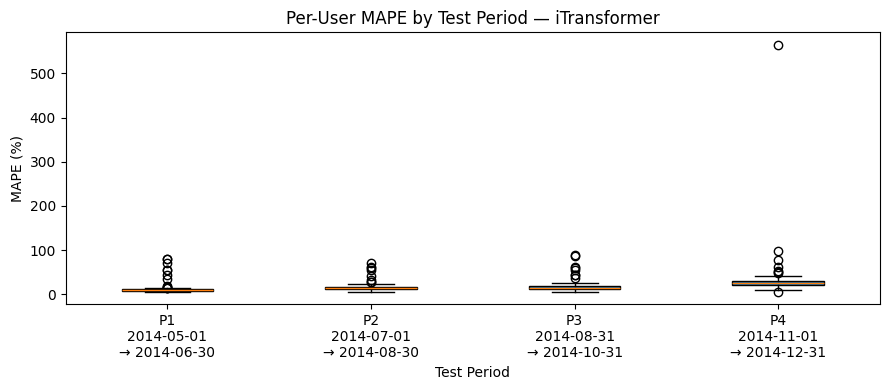

In [13]:
# Box plot of per-user MAPE per period
fig, ax = plt.subplots(figsize=(9, 4))
box_data    = []
tick_labels = []

for period in protocol["equal_size_test_periods"]:
    p_start = pd.Timestamp(period["start"])
    p_end   = pd.Timestamp(period["end"])
    mask    = (test_eval["ds"] >= p_start) & (test_eval["ds"] <= p_end)
    p_df    = test_eval[mask]

    per_user_mapes = []
    for uid, grp in p_df.groupby("unique_id"):
        y, yhat = grp["y"].values, grp["iTransformer"].values
        pos    = y > 0
        mape_u = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
        per_user_mapes.append(mape_u)

    box_data.append([v for v in per_user_mapes if not np.isnan(v)])
    tick_labels.append(
        f"P{period['period_id']}\n{period['start'][:10]}\n→ {period['end'][:10]}"
    )

ax.boxplot(box_data, labels=tick_labels, patch_artist=True)
ax.set_title("Per-User MAPE by Test Period — iTransformer")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Test Period")
plt.tight_layout()
plt.show()

In [14]:
# PER-CLUSTER EVALUATION METRICS — Test Set

cluster_metric_rows = []
for label, users in cluster_groups.items():
    cluster_df = test_eval[test_eval["unique_id"].isin(users)]
    if cluster_df.empty:
        continue
    metrics = compute_metrics(cluster_df)
    cluster_metric_rows.append({"cluster": label, "n_users": len(users), **metrics})

# Overall row
overall = compute_metrics(test_eval)
cluster_metric_rows.append({"cluster": "OVERALL", "n_users": test_eval["unique_id"].nunique(), **overall})

cluster_metrics_df = pd.DataFrame(cluster_metric_rows)
print("-- Test Metrics by Cluster --")
print(cluster_metrics_df.to_string(index=False))

-- Test Metrics by Cluster --
  cluster  n_users         MSE      MAE    MAPE   WAPE
cluster_0       84 226492.8797 104.6282 15.8693 0.1350
cluster_1       64  82570.2494  88.4609 17.6259 0.1537
 outliers        8  34850.3844 109.5916 47.1124 0.1803
  OVERALL      156 157619.8778  98.2500 18.1073 0.1435


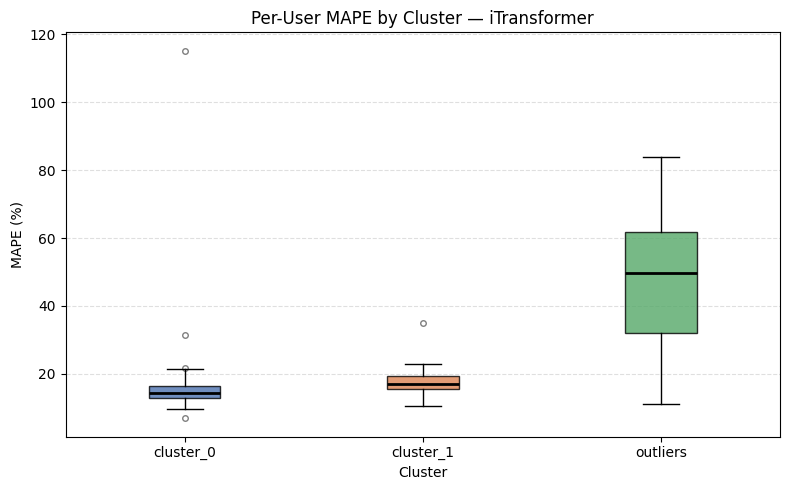

In [15]:
# BOX PLOT: Per-User MAPE by Cluster — iTransformer

# Compute per-user MAPE over the full test period
per_user_mapes = {}
for uid, grp in test_eval.groupby("unique_id"):
    y, yhat = grp["y"].values, grp["iTransformer"].values
    pos = y > 0
    mape_u = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
    per_user_mapes[uid] = mape_u

# Group MAPEs by cluster using cluster_groups
box_data = []
labels   = []
for label, users in cluster_groups.items():
    mapes = [per_user_mapes[u] for u in users
             if u in per_user_mapes and not np.isnan(per_user_mapes[u])]
    box_data.append(mapes)
    labels.append(label)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    box_data, labels=labels, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
)
colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title("Per-User MAPE by Cluster — iTransformer")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Cluster")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / "cluster_boxplot_itransformer.png", dpi=150)
plt.show()

In [ ]:
import shutil

# Zip the entire models directory into one archive
shutil.make_archive("/content/itransformer_models", "zip", str(MODEL_DIR))
print("Zipped all model weights -> itransformer_models.zip")

In [ ]:
from google.colab import files

files.download("/content/itransformer_models.zip")